In [1]:
import os
import cv2
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_multiple(images,names=None,nrows=4, figsize=(5, 5),save_name=None):
    # Assuming 'images' is a list of your image arrays
    # Let's say we want 2 rows
    n_images = len(images)
    ncols = (n_images + nrows - 1) // nrows  # Ceiling division to calculate columns

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten the axes array in case it's 2D, making it easy to loop over
    for i, ax in enumerate(axes.flat):
        if i < n_images:
            ax.imshow(images[i])
            ax.set_title(f"{names[i]}")
            ax.axis('off') # Hide tick marks
        else:
            ax.axis('off') # Hide empty subplots    
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=600)
    plt.show()

In [3]:
root_raw_dir = "/mnt/ssd/datasets/deepfake/200k_live_face_dataset/live"
list_dirs = ["/mnt/ssd/datasets/deepfake/200k_24nov/fake/blendface",
#"/mnt/ssd/datasets/deepfake/200k_24nov/fake/e4s/",
#"/mnt/ssd/datasets/deepfake/200k_24nov/fake/inswapper",
"/mnt/ssd/datasets/deepfake/200k_24nov/fake/mobilefaceswap",
"/mnt/ssd/datasets/deepfake/200k_24nov/fake/reswapper",
"/mnt/ssd/datasets/deepfake/200k_24nov/fake/uniface",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/cscs",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/cscs_enhanced",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/ghostface",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/ghostface_enhanced",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/instyleswapper",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/instyleswapper_enhanced",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/inswapper",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/inswapper_enhanced",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/simswap",
"/mnt/ssd/workspace/adi/repos/VisoMaster/generated_swaps/pair-200k_live_face_dataset-24nov/simswap_enhanced",
"/mnt/ssd/workspace/adi/repos/HeadSwap/generated_swap/HeSer",
"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/deepfake_generator/BFS-BestFaceSwap/generated_swaps/pair-200k_live_face_dataset-24nov",
"/mnt/ssd/workspace/adi/repos/REFace/generated_swaps/pair-200k_live_face_dataset-24nov"
]

In [4]:
list_files = []
for i in list_dirs:
    #list_now = [j for j in os.listdir(i)]
    list_files.append(os.listdir(i))

#list_files[1] = [j[5:] for j in list_files[1]]

# 1. Convert lists to a list of sets
sets = [set(lst) for lst in list_files]

# 2. Intersect all sets
common_elements = list(set.intersection(*sets))
del list_files
del sets

In [5]:
print(len(list_dirs))
len(common_elements)

17


10856

In [6]:
print(len(os.listdir(list_dirs[-2])))

11299


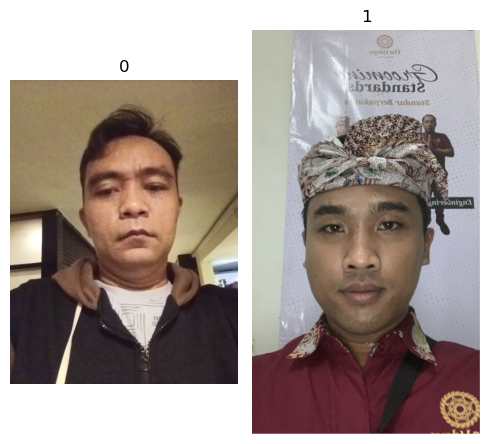

In [14]:
filenow = common_elements[35]
imgs = filenow.split(".")[0].split("_to_")
real_images = []
for i in imgs:
    real_images.append(np.array(Image.open(os.path.join(root_raw_dir,i+".jpg.jpg"))))
plot_multiple(real_images,names=[str(i) for i in range(len(real_images))],nrows=1) 
#plot_multiple(real_images,names=["image1","image2"],nrows=1)
    #plt.imshow(img_now)

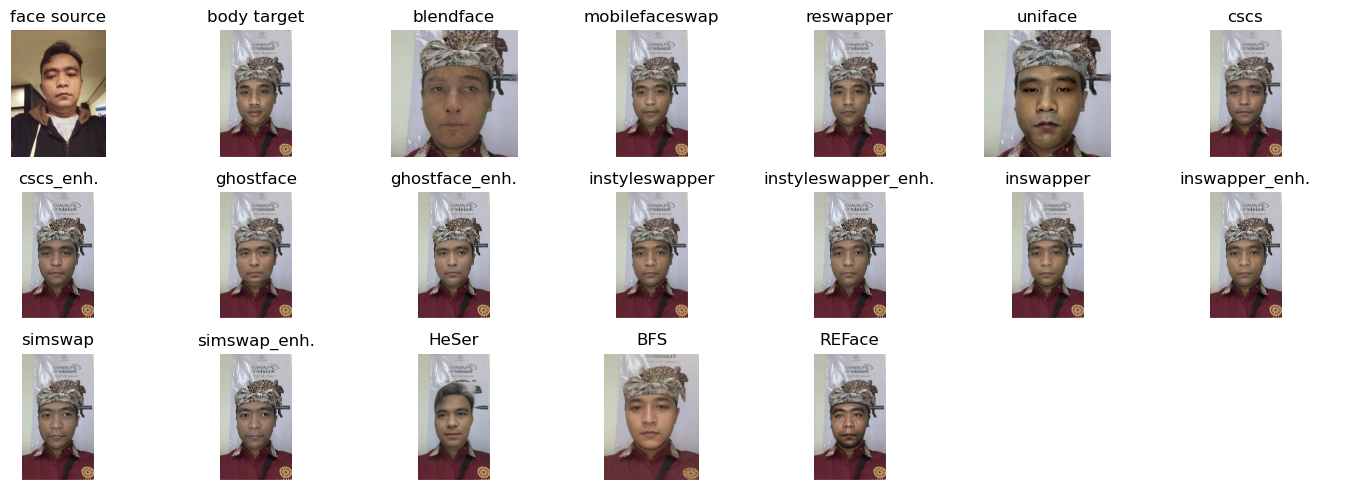

In [15]:
images = real_images.copy()
#filenow = common_elements[0]
for i in list_dirs:
    images.append(cv2.cvtColor(cv2.imread(os.path.join(i,filenow)),cv2.COLOR_BGR2RGB))

names = ["face source","body target"]+[i.split('/')[-1] for i in list_dirs[:-2]]+["BFS","REFace"]
names = [i.replace("enhanced", "enh.") for i in names]
plot_multiple(images,names=names,nrows=3,figsize=(14,5),save_name="example_plot_new.jpg")
#plot_multiple(images,names=[str(i) for i in range(len(images))],nrows=3,figsize=(10,5)) 

#### Saving Images

In [27]:
for i,img in enumerate(images):
    cv2.imwrite(f'sample_images/pair_d/{names[i]}.jpg', cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


In [14]:
images[0]

array([[[ 34,  30,  31],
        [ 35,  31,  32],
        [ 36,  32,  33],
        ...,
        [ 34,  25,  26],
        [ 33,  24,  25],
        [ 33,  24,  25]],

       [[ 34,  30,  31],
        [ 35,  31,  32],
        [ 36,  32,  33],
        ...,
        [ 33,  24,  25],
        [ 33,  24,  25],
        [ 33,  24,  25]],

       [[ 32,  30,  31],
        [ 34,  32,  33],
        [ 35,  33,  34],
        ...,
        [ 32,  23,  24],
        [ 33,  24,  25],
        [ 33,  24,  25]],

       ...,

       [[245, 253, 255],
        [246, 254, 255],
        [247, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[247, 252, 255],
        [247, 252, 255],
        [248, 253, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[246, 251, 254],
        [247, 252, 255],
        [248, 253, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [ ]:
for c

In [9]:
names

['blendface',
 'inswapper',
 'mobilefaceswap',
 'reswapper',
 'uniface',
 'cscs',
 'cscs_enhanced',
 'ghostface',
 'ghostface_enhanced',
 'instyleswapper',
 'instyleswapper_enhanced',
 'simswap',
 'simswap_enhanced',
 'BFS']

In [ ]:
imgs[0]+".jpg.jpg"

'85819_verify_42a3403c-3d14-4179-9ff1-0c65b45974b3_ca7dadec-485e-40c8-ac62-4a9b976b741c_original.jpg.jpg'

In [ ]:
names = [i.split('/')[-1] for i in list_dirs[:14]]+["BFS"]

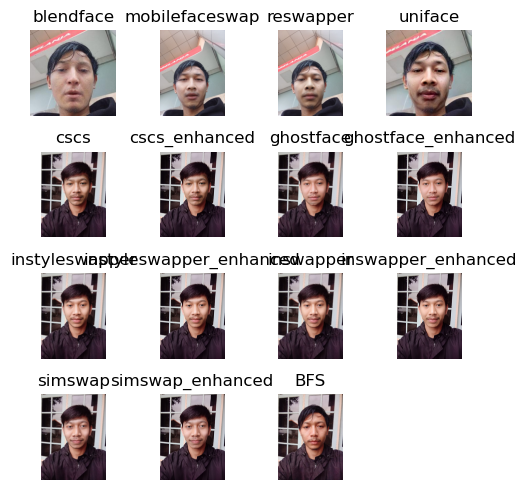

In [6]:
list_files[-2][0]

'33661_liveness_obv_spoof_sync_ab8d11b3-3dd7-4192-b032-ca4e2303c5aa_f0c77887-6df9-4c6a-9dad-a5e26a551646_original_to_179027_verify_f257faf5-4323-4953-9786-f404dbf5acf4_c4a8a990-2be5-494f-b39c-f38b2017cede_original.jpg'

### Find pairs

In [24]:
substring = common_elements[0].split("_to_")[0]

In [25]:
substring

'31044_verify_2ef7e08f-78c4-40aa-b38c-255cbaf85fd2_9fae95ca-74be-4bd9-af82-31e01676a147_original'

In [26]:
list_check = os.listdir(list_dirs[-1])

In [30]:
print(common_elements[0])
#substring = "42459_verify_7ba52281-7a9b-4ded-a811-50e03234aa9f_66c95729-e7b1-46d5-977d-5860494a95f9_original"
#substring = "154644_verify_969c1205-db5c-4d09-af40-4d0ff07414ec_2e0d0189-22af-4126-8dfb-23ed20bf6b3e_original"
for index, s in enumerate(list_check):
    if substring in s:
        print(f"Found at list index {index}: '{s}'")
        #break
#else:
#    print("Not found")

31044_verify_2ef7e08f-78c4-40aa-b38c-255cbaf85fd2_9fae95ca-74be-4bd9-af82-31e01676a147_original_to_184334_verify_fd46caa8-139f-4265-b449-90e32e74bf5e_b37dd34e-c39c-4b78-b50a-9ae62727eb33_original.jpg
Found at list index 6046: '184334_verify_fd46caa8-139f-4265-b449-90e32e74bf5e_b37dd34e-c39c-4b78-b50a-9ae62727eb33_original_to_31044_verify_2ef7e08f-78c4-40aa-b38c-255cbaf85fd2_9fae95ca-74be-4bd9-af82-31e01676a147_original.jpg'


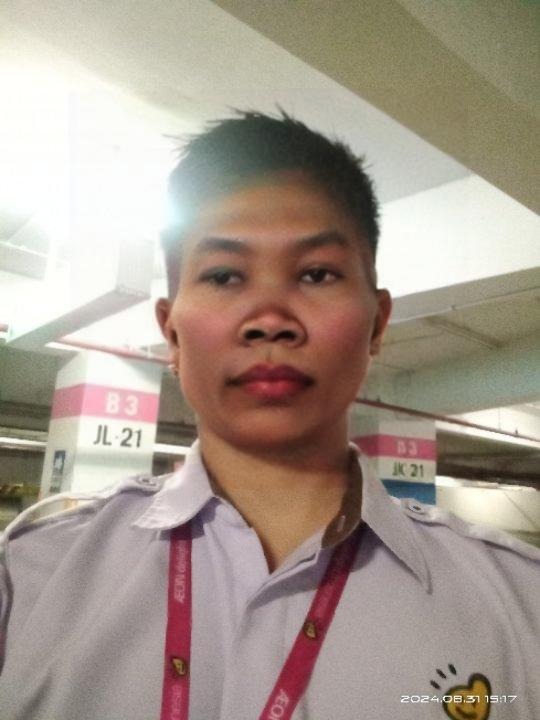

In [31]:
Image.open(os.path.join(list_dirs[-1],"184334_verify_fd46caa8-139f-4265-b449-90e32e74bf5e_b37dd34e-c39c-4b78-b50a-9ae62727eb33_original_to_31044_verify_2ef7e08f-78c4-40aa-b38c-255cbaf85fd2_9fae95ca-74be-4bd9-af82-31e01676a147_original.jpg"))

In [8]:
list_files[3][:10]

['203728_verify_54fa8bc6-d416-4d9d-8d37-d7efb62b0681_603b5842-4681-4499-84ec-075b0fc642f0_original_to_115982_verify_7471d236-d16b-4e9f-9b47-e4fdd1060f23_07a11d9e-d292-4c5b-bbe6-3f7c804bb881_original.jpg',
 '34313_verify_e8f35a68-7432-46d3-a0da-27e1ba96a102_9fe9d4dc-9cfe-4878-be00-1fc68fc6cabf_original_to_86946_verify_5384bebe-2a88-4ab7-8395-a1adf8b008bc_54d53426-66d5-48b0-9379-33fd753174a7_original.jpg',
 '64232_verify_2836883b-c6af-40df-b4a0-ee0aadd702c0_883d7a28-ee24-4dad-aa8d-0eb67c9cf806_original_to_110841_verify_70267b72-3e3f-43ad-b2f6-c8445a69787f_c25add4e-7497-4c28-8796-447052713516_original.jpg',
 '218644_verify_688a6df1-9983-4a9e-8408-ddcaaac6220e_35937e5b-8743-405b-b11e-dcde674f3419_original_to_221616_verify_b43dc2d5-843a-4e34-ab5e-b9d3d98342d8_ecd9cee5-db5d-430a-8592-a45e469b1c32_original.jpg',
 '225339_verify_512048b6-2414-41b6-9851-cbcaf913d494_bbdf9933-6ea5-4570-abcc-fc975c8b719e_original_to_89834_verify_da5aceab-3691-4575-91bb-e2b68304c354_06e72f52-3110-45af-96e5-0754848

In [9]:
from PIL import Image

In [12]:
image1 = "20298_verify_2e5c7581-a5dd-44d8-8c76-25d1c179f227_57fb245a-9fed-4619-a558-62705d520e5b_original_to_42459_verify_7ba52281-7a9b-4ded-a811-50e03234aa9f_66c95729-e7b1-46d5-977d-5860494a95f9_original.jpg"
image2 = "42459_verify_7ba52281-7a9b-4ded-a811-50e03234aa9f_66c95729-e7b1-46d5-977d-5860494a95f9_original_to_20298_verify_2e5c7581-a5dd-44d8-8c76-25d1c179f227_57fb245a-9fed-4619-a558-62705d520e5b_original.jpg"

folder1 = "/mnt/ssd/datasets/deepfake/200k_24nov/fake/reswapper/"
folder2 = "/mnt/ssd/workspace/adi/repos/REFace/generated_swaps/pair-200k_live_face_dataset-24nov"

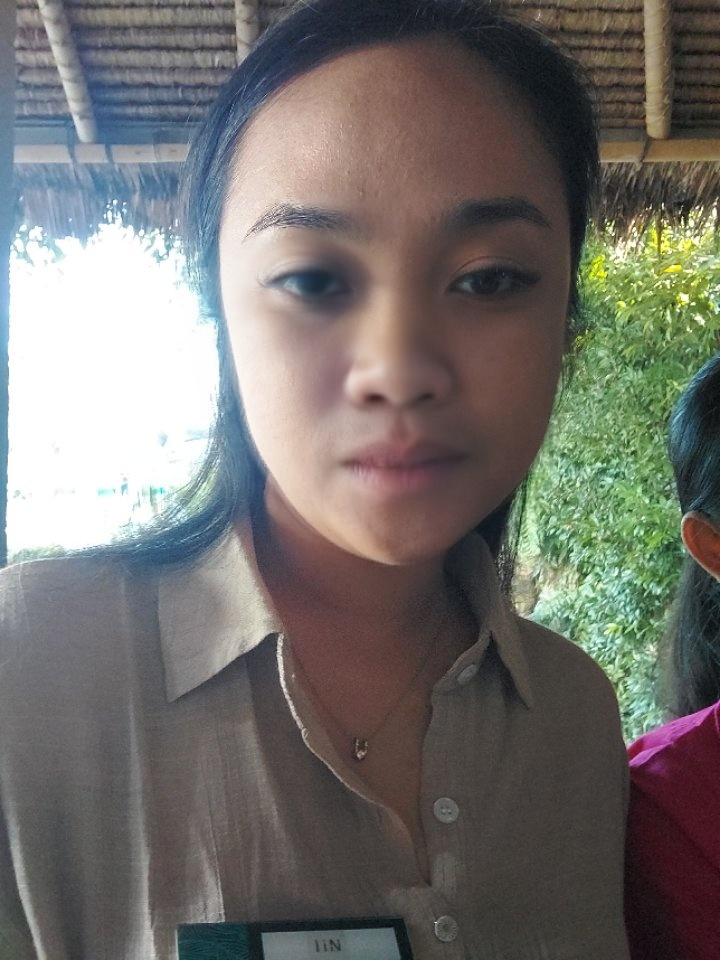

In [14]:
Image.open(os.path.join(folder1,image1))

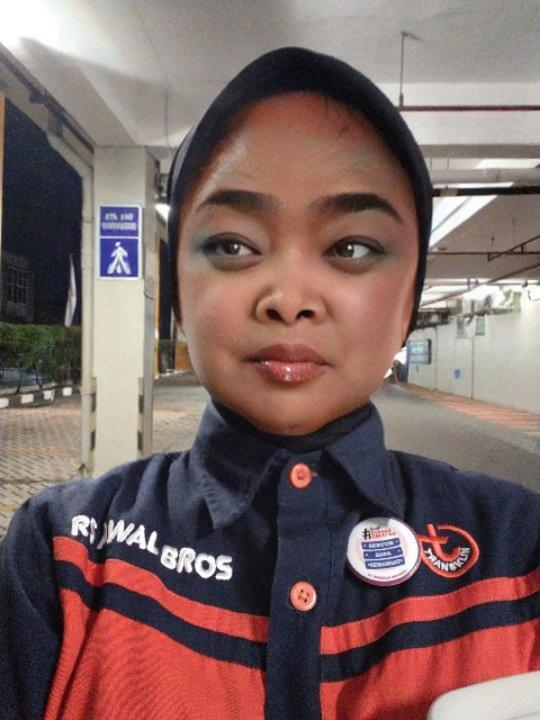

In [15]:
Image.open(os.path.join(folder2,image2))